# 🫀 Projet Machine Learning - IFOAD
## Analyse et Prédiction des Maladies Cardiaques
**Dataset:** Heart Disease UCI  
**Auteur:** [Ton Nom]  
**Encadreur:** Dr Arthur Sawadogo

---
# 📦 ÉTAPE 0 : Installation et Importation des Bibliothèques

In [1]:
# Installation des bibliothèques nécessaires
# !pip install pandas numpy matplotlib seaborn scikit-learn ucimlrepo

In [2]:
# ── Manipulation des données ──
import pandas as pd
import numpy as np

# ── Visualisation ──
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Machine Learning ──
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

# ── Algorithmes de Classification ──
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# ── Paramètres d'affichage ──
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

print('✅ Toutes les bibliothèques sont importées avec succès !')

✅ Toutes les bibliothèques sont importées avec succès !


---
# 📥 ÉTAPE 1 : Chargement des Données

In [3]:
# ── Méthode 1 : Téléchargement via ucimlrepo (recommandé) ──
from ucimlrepo import fetch_ucirepo

heart_disease = fetch_ucirepo(id=45)
X_raw = heart_disease.data.features
y_raw = heart_disease.data.targets

# Combinaison en un seul DataFrame
df = X_raw.copy()
df['target'] = y_raw.values

# Convertir target en binaire (0 = pas de maladie, 1 = maladie)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print(f'✅ Dataset chargé avec succès !')
print(f'📊 Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes')

✅ Dataset chargé avec succès !
📊 Dimensions : 303 lignes x 14 colonnes


In [4]:
# ── Méthode alternative : Chargement depuis un fichier CSV ──
# Si tu as téléchargé le CSV manuellement, décommente et utilise cette ligne :
# df = pd.read_csv('heart.csv')
# df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# Aperçu des premières lignes
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
5,56,1,2,120,236,0,0,178,0,0.8,1,0.0,3.0,0
6,62,0,4,140,268,0,2,160,0,3.6,3,2.0,3.0,1
7,57,0,4,120,354,0,0,163,1,0.6,1,0.0,3.0,0
8,63,1,4,130,254,0,2,147,0,1.4,2,1.0,7.0,1
9,53,1,4,140,203,1,2,155,1,3.1,3,0.0,7.0,1


---
# 🔍 ÉTAPE 2 : Exploration Initiale des Données (EDA)

In [5]:
# ── Informations générales ──
print('='*60)
print('📋 INFORMATIONS GÉNÉRALES DU DATASET')
print('='*60)
df.info()

📋 INFORMATIONS GÉNÉRALES DU DATASET
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [6]:
# ── Statistiques descriptives ──
print('='*60)
print('📊 STATISTIQUES DESCRIPTIVES')
print('='*60)
df.describe().round(2)

📊 STATISTIQUES DESCRIPTIVES


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


In [7]:
# ── Vérification des valeurs manquantes ──
print('='*60)
print('❓ VALEURS MANQUANTES PAR COLONNE')
print('='*60)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Manquantes': missing, 'Pourcentage (%)': missing_pct.round(2)})
print(missing_df)
print(f'\n✅ Total valeurs manquantes : {df.isnull().sum().sum()}')

❓ VALEURS MANQUANTES PAR COLONNE
          Manquantes  Pourcentage (%)
age                0             0.00
sex                0             0.00
cp                 0             0.00
trestbps           0             0.00
chol               0             0.00
fbs                0             0.00
restecg            0             0.00
thalach            0             0.00
exang              0             0.00
oldpeak            0             0.00
slope              0             0.00
ca                 4             1.32
thal               2             0.66
target             0             0.00

✅ Total valeurs manquantes : 6


🎯 DISTRIBUTION DE LA VARIABLE CIBLE (target)
Pas de maladie (0) : 164 patients (54.1%)
Maladie cardiaque (1) : 139 patients (45.9%)


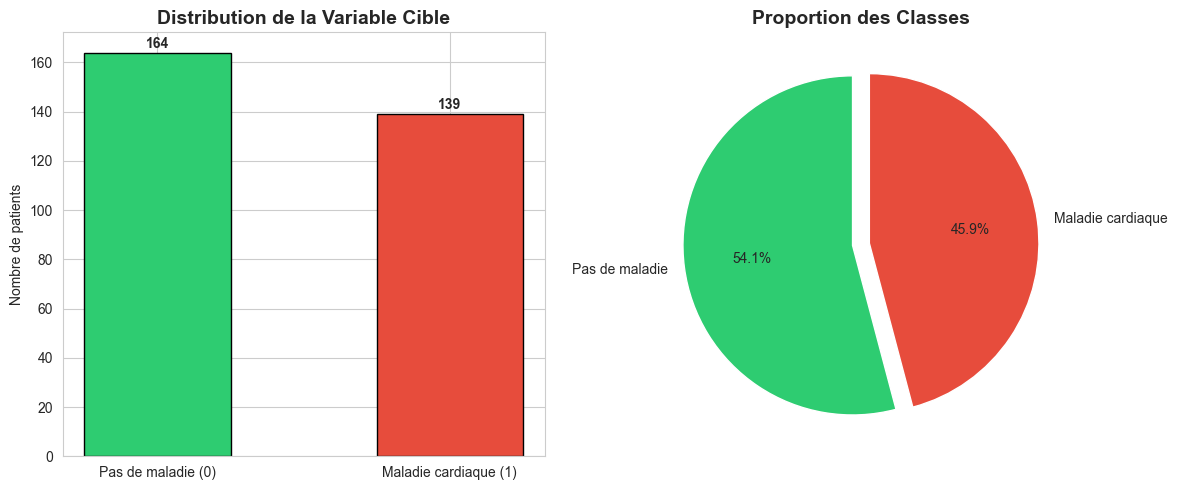

In [8]:
# ── Distribution de la variable cible ──
print('='*60)
print('🎯 DISTRIBUTION DE LA VARIABLE CIBLE (target)')
print('='*60)
target_counts = df['target'].value_counts()
print(f"Pas de maladie (0) : {target_counts[0]} patients ({target_counts[0]/len(df)*100:.1f}%)")
print(f"Maladie cardiaque (1) : {target_counts[1]} patients ({target_counts[1]/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot
axes[0].bar(['Pas de maladie (0)', 'Maladie cardiaque (1)'],
            [target_counts[0], target_counts[1]],
            color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
axes[0].set_title('Distribution de la Variable Cible', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Nombre de patients')
for i, v in enumerate([target_counts[0], target_counts[1]]):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie([target_counts[0], target_counts[1]],
            labels=['Pas de maladie', 'Maladie cardiaque'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Proportion des Classes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('distribution_target.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 📊 ÉTAPE 3 : Analyse Exploratoire - Réponse aux Questions du Projet

## ❓ Question 1 : Quelle est la distribution de l'âge des individus ?

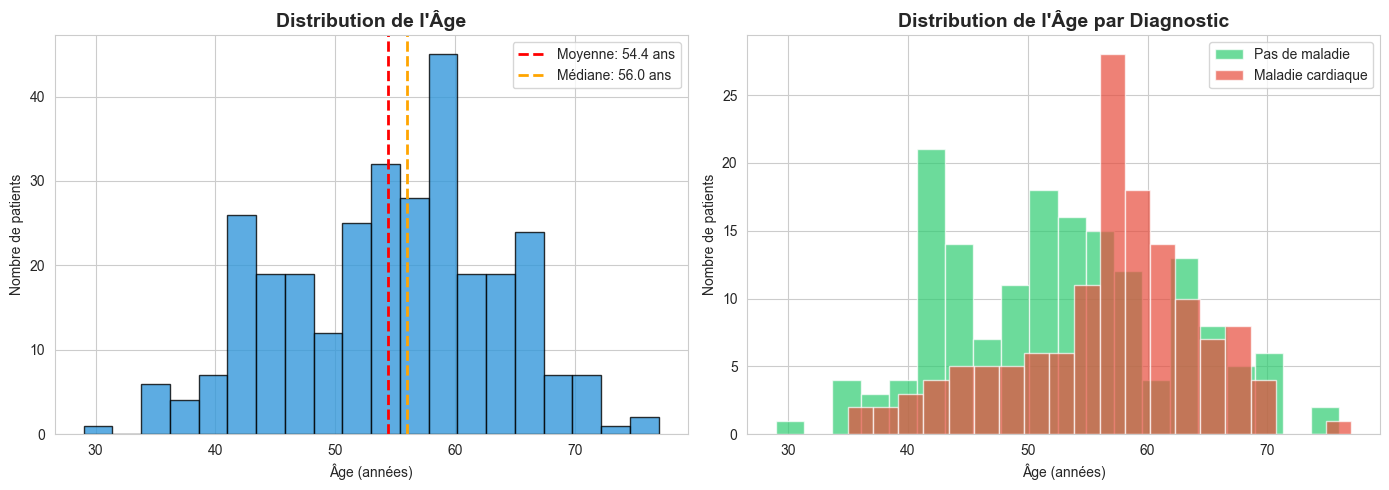


📊 Statistiques sur l'âge :
  • Âge minimum  : 29 ans
  • Âge maximum  : 77 ans
  • Âge moyen    : 54.4 ans
  • Âge médian   : 56.0 ans
  • Écart-type   : 9.0 ans


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme de l'âge
axes[0].hist(df['age'], bins=20, color='#3498db', edgecolor='black', alpha=0.8)
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2, label=f"Moyenne: {df['age'].mean():.1f} ans")
axes[0].axvline(df['age'].median(), color='orange', linestyle='--', linewidth=2, label=f"Médiane: {df['age'].median():.1f} ans")
axes[0].set_title('Distribution de l\'Âge', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Âge (années)')
axes[0].set_ylabel('Nombre de patients')
axes[0].legend()

# Distribution de l'âge par classe
df[df['target']==0]['age'].hist(bins=20, alpha=0.7, color='#2ecc71', label='Pas de maladie', ax=axes[1])
df[df['target']==1]['age'].hist(bins=20, alpha=0.7, color='#e74c3c', label='Maladie cardiaque', ax=axes[1])
axes[1].set_title('Distribution de l\'Âge par Diagnostic', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Âge (années)')
axes[1].set_ylabel('Nombre de patients')
axes[1].legend()

plt.tight_layout()
plt.savefig('distribution_age.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Statistiques sur l'âge :")
print(f"  • Âge minimum  : {df['age'].min()} ans")
print(f"  • Âge maximum  : {df['age'].max()} ans")
print(f"  • Âge moyen    : {df['age'].mean():.1f} ans")
print(f"  • Âge médian   : {df['age'].median():.1f} ans")
print(f"  • Écart-type   : {df['age'].std():.1f} ans")

## ❓ Question 2 : Y a-t-il une différence dans la présence de maladie cardiaque entre les sexes ?

Tableau croisé Sexe x Maladie Cardiaque :
           Pas de maladie  Maladie cardiaque
Femme (0)              72                 25
Homme (1)              92                114

Pourcentage par sexe :
           Pas de maladie  Maladie cardiaque
Femme (0)            74.2               25.8
Homme (1)            44.7               55.3


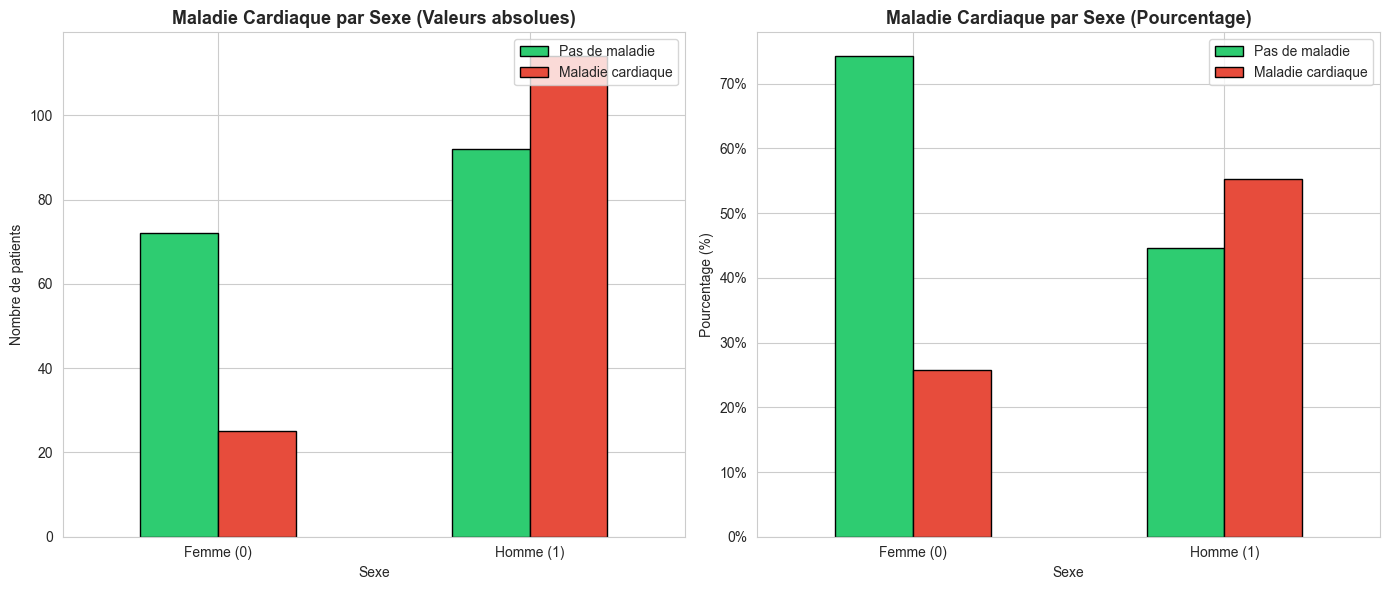

In [10]:
# Tableau croisé sexe x maladie
sex_disease = pd.crosstab(df['sex'], df['target'],
                           rownames=['Sexe'], colnames=['Maladie cardiaque'])
sex_disease.index = ['Femme (0)', 'Homme (1)']
sex_disease.columns = ['Pas de maladie', 'Maladie cardiaque']
print('Tableau croisé Sexe x Maladie Cardiaque :')
print(sex_disease)

# Pourcentage par sexe
sex_disease_pct = sex_disease.div(sex_disease.sum(axis=1), axis=0) * 100
print('\nPourcentage par sexe :')
print(sex_disease_pct.round(1))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sex_disease.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'],
                 edgecolor='black', rot=0)
axes[0].set_title('Maladie Cardiaque par Sexe (Valeurs absolues)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sexe')
axes[0].set_ylabel('Nombre de patients')
axes[0].legend(loc='upper right')

sex_disease_pct.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'],
                     edgecolor='black', rot=0)
axes[1].set_title('Maladie Cardiaque par Sexe (Pourcentage)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sexe')
axes[1].set_ylabel('Pourcentage (%)')
axes[1].legend(loc='upper right')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.tight_layout()
plt.savefig('maladie_par_sexe.png', dpi=150, bbox_inches='tight')
plt.show()

## ❓ Question 3 : Comment le type de douleur thoracique (cp) est-il lié à la maladie cardiaque ?

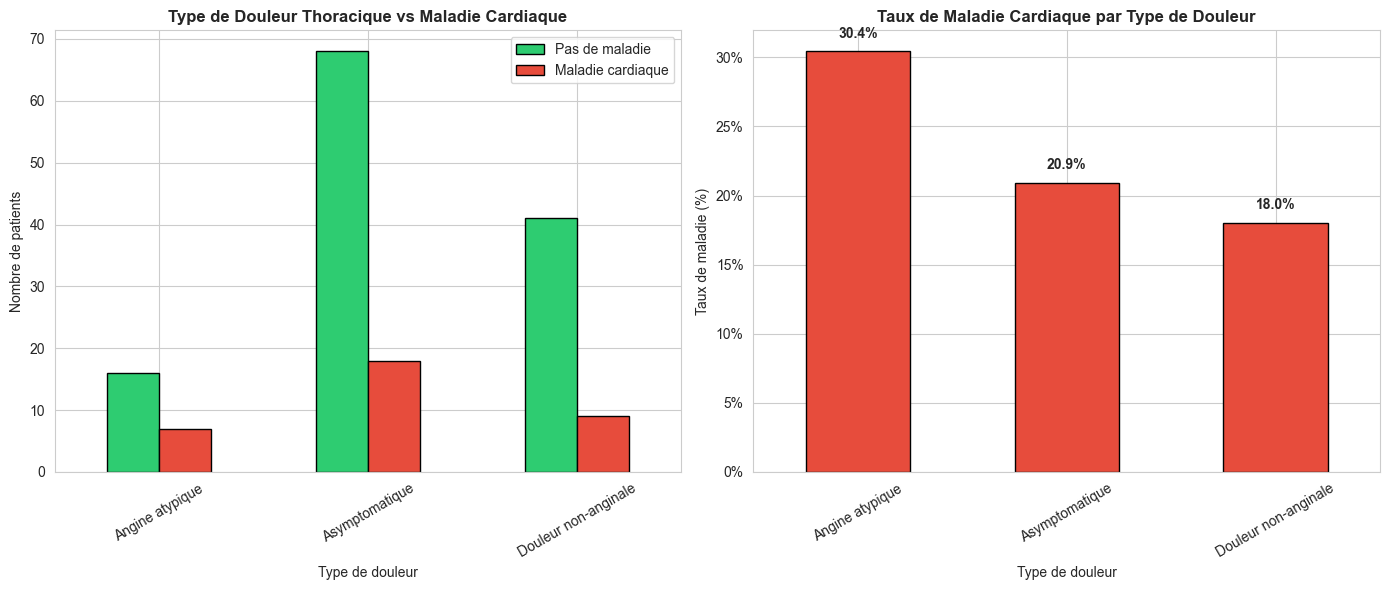

In [11]:
cp_labels = {
    0: 'Angine typique',
    1: 'Angine atypique',
    2: 'Douleur non-anginale',
    3: 'Asymptomatique'
}
df['cp_label'] = df['cp'].map(cp_labels)

cp_disease = pd.crosstab(df['cp_label'], df['target'])
cp_disease.columns = ['Pas de maladie', 'Maladie cardiaque']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cp_disease.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'],
                edgecolor='black', rot=30)
axes[0].set_title('Type de Douleur Thoracique vs Maladie Cardiaque', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Type de douleur')
axes[0].set_ylabel('Nombre de patients')
axes[0].legend()

# Taux de maladie par type de douleur
cp_rate = df.groupby('cp_label')['target'].mean() * 100
cp_rate.plot(kind='bar', ax=axes[1], color='#e74c3c', edgecolor='black', rot=30)
axes[1].set_title('Taux de Maladie Cardiaque par Type de Douleur', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Type de douleur')
axes[1].set_ylabel('Taux de maladie (%)')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
for i, v in enumerate(cp_rate):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('douleur_thoracique.png', dpi=150, bbox_inches='tight')
plt.show()

# Supprimer la colonne temporaire
df.drop('cp_label', axis=1, inplace=True)

## ❓ Question 4 : Valeurs moyennes de trestbps, chol et thalach avec et sans maladie ?

Valeurs moyennes par diagnostic :
                   trestbps    chol  thalach
Pas de maladie       129.25  242.64   158.38
Maladie cardiaque    134.57  251.47   139.26


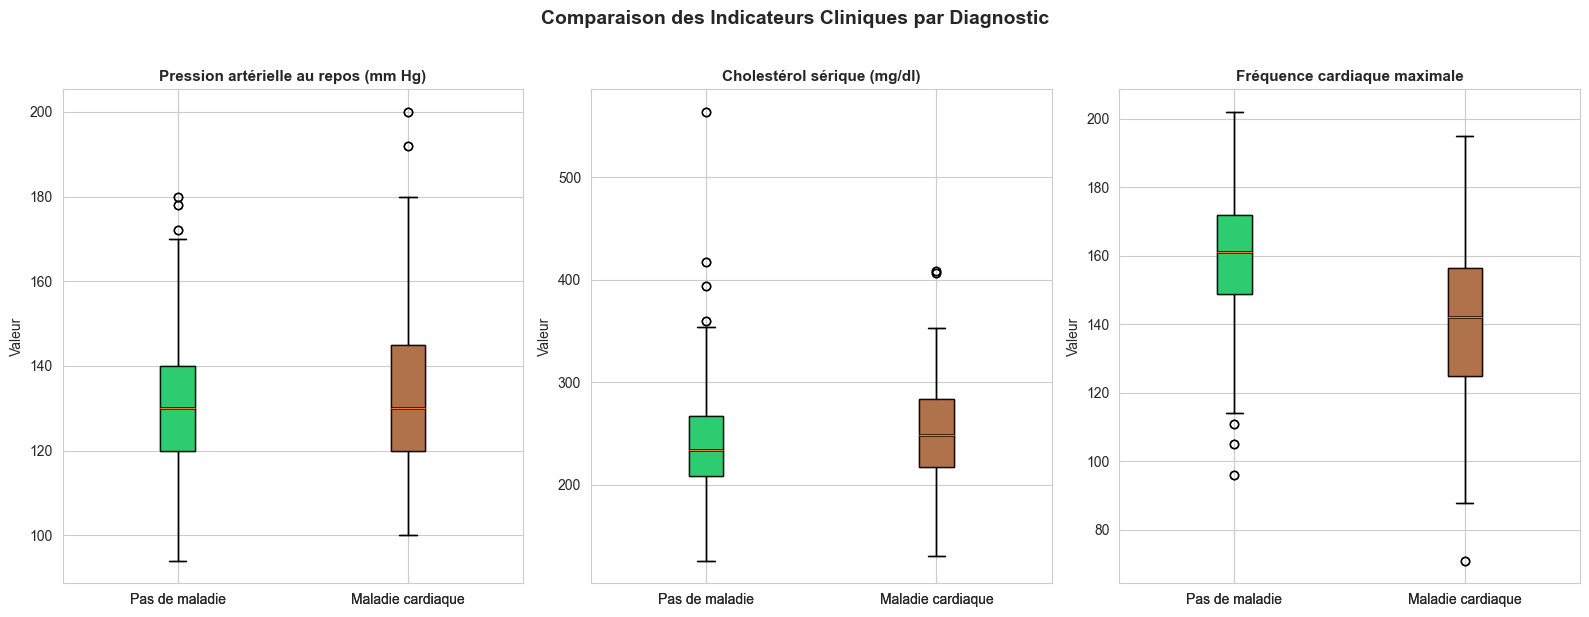

In [12]:
variables_cles = ['trestbps', 'chol', 'thalach']
labels = {
    'trestbps': 'Pression artérielle au repos (mm Hg)',
    'chol': 'Cholestérol sérique (mg/dl)',
    'thalach': 'Fréquence cardiaque maximale'
}

# Tableau des moyennes
moyennes = df.groupby('target')[variables_cles].mean().round(2)
moyennes.index = ['Pas de maladie', 'Maladie cardiaque']
print('Valeurs moyennes par diagnostic :')
print(moyennes)

# Visualisation avec boxplots
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for i, var in enumerate(variables_cles):
    data_0 = df[df['target'] == 0][var]
    data_1 = df[df['target'] == 1][var]
    axes[i].boxplot([data_0, data_1],
                    labels=['Pas de maladie', 'Maladie cardiaque'],
                    patch_artist=True,
                    boxprops=dict(facecolor=['#2ecc71', '#e74c3c'][0]),
                    medianprops=dict(color='black', linewidth=2))
    boxes = axes[i].patches
    colors = ['#2ecc71', '#e74c3c']
    bp = axes[i].boxplot([data_0, data_1],
                         labels=['Pas de maladie', 'Maladie cardiaque'],
                         patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(labels[var], fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Valeur')

plt.suptitle('Comparaison des Indicateurs Cliniques par Diagnostic', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('boxplots_cliniques.png', dpi=150, bbox_inches='tight')
plt.show()

## ❓ Question 5 : La glycémie à jeun (fbs > 120 mg/dl) est-elle associée à la maladie cardiaque ?

Glycémie à jeun vs Maladie Cardiaque :
                         Pas de maladie  Maladie cardiaque
Glycémie normale (≤120)             141                117
Glycémie élevée (>120)               23                 22


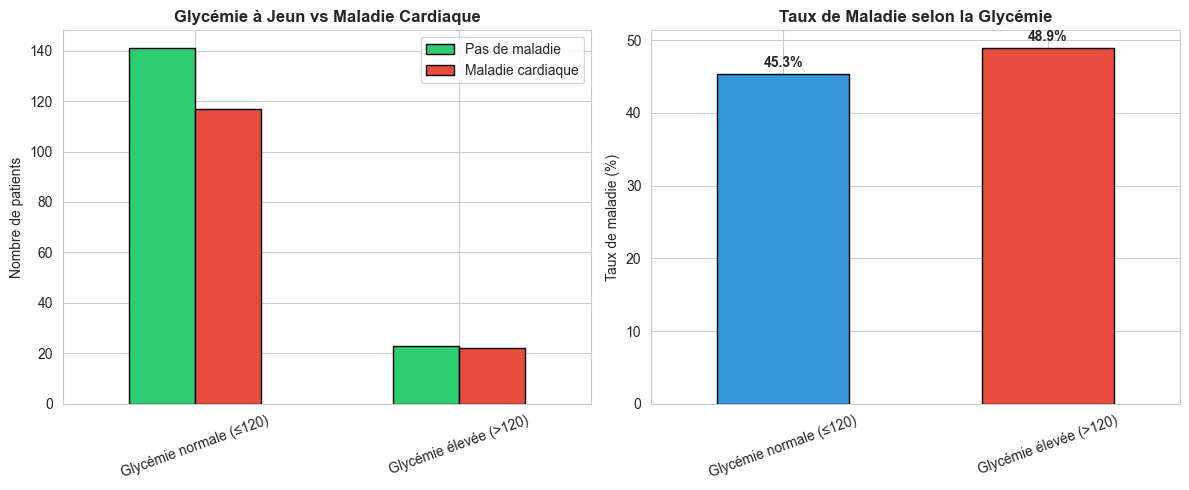

In [13]:
fbs_disease = pd.crosstab(df['fbs'], df['target'])
fbs_disease.index = ['Glycémie normale (≤120)', 'Glycémie élevée (>120)']
fbs_disease.columns = ['Pas de maladie', 'Maladie cardiaque']
print('Glycémie à jeun vs Maladie Cardiaque :')
print(fbs_disease)

fbs_rate = df.groupby('fbs')['target'].mean() * 100
fbs_rate.index = ['Glycémie normale (≤120)', 'Glycémie élevée (>120)']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fbs_disease.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'],
                 edgecolor='black', rot=20)
axes[0].set_title('Glycémie à Jeun vs Maladie Cardiaque', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Nombre de patients')
axes[0].legend()

fbs_rate.plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'],
              edgecolor='black', rot=20)
axes[1].set_title('Taux de Maladie selon la Glycémie', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Taux de maladie (%)')
for i, v in enumerate(fbs_rate):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('glycemie_maladie.png', dpi=150, bbox_inches='tight')
plt.show()

## ❓ Question 6 : Comment l'angine induite par l'exercice (exang) est-elle corrélée à la maladie ?

Angine à l'exercice vs Maladie Cardiaque :
                         Pas de maladie  Maladie cardiaque
Pas d'angine (0)                    141                 63
Angine à l'exercice (1)              23                 76


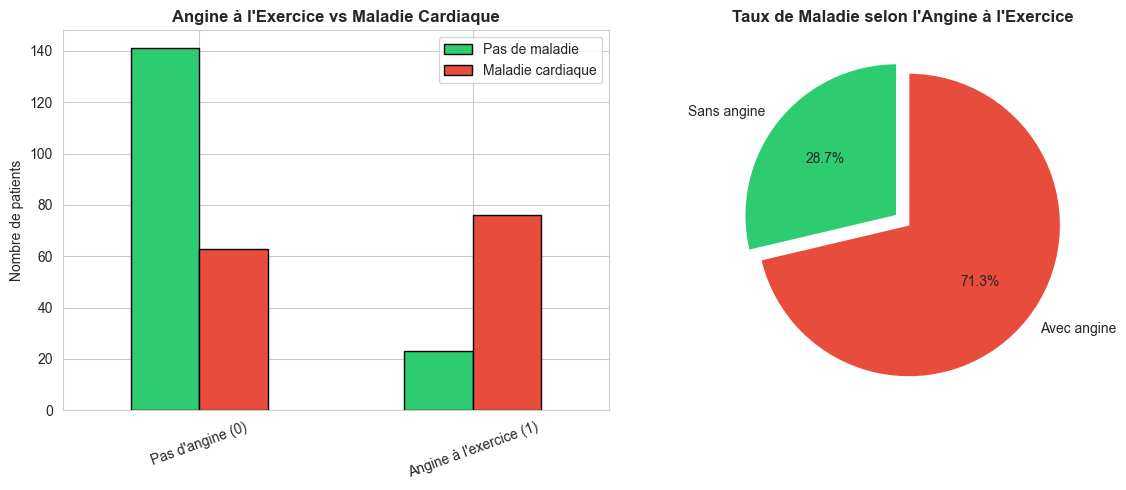


📊 Taux de maladie cardiaque :
  • Sans angine à l'exercice : 30.9%
  • Avec angine à l'exercice : 76.8%


In [14]:
exang_disease = pd.crosstab(df['exang'], df['target'])
exang_disease.index = ['Pas d\'angine (0)', 'Angine à l\'exercice (1)']
exang_disease.columns = ['Pas de maladie', 'Maladie cardiaque']
print('Angine à l\'exercice vs Maladie Cardiaque :')
print(exang_disease)

exang_rate = df.groupby('exang')['target'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

exang_disease.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'],
                   edgecolor='black', rot=20)
axes[0].set_title('Angine à l\'Exercice vs Maladie Cardiaque', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Nombre de patients')
axes[0].legend()

axes[1].pie(exang_rate.values,
            labels=['Sans angine', 'Avec angine'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Taux de Maladie selon l\'Angine à l\'Exercice', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('angine_maladie.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Taux de maladie cardiaque :")
print(f"  • Sans angine à l'exercice : {exang_rate[0]:.1f}%")
print(f"  • Avec angine à l'exercice : {exang_rate[1]:.1f}%")

## 📈 Matrice de Corrélation

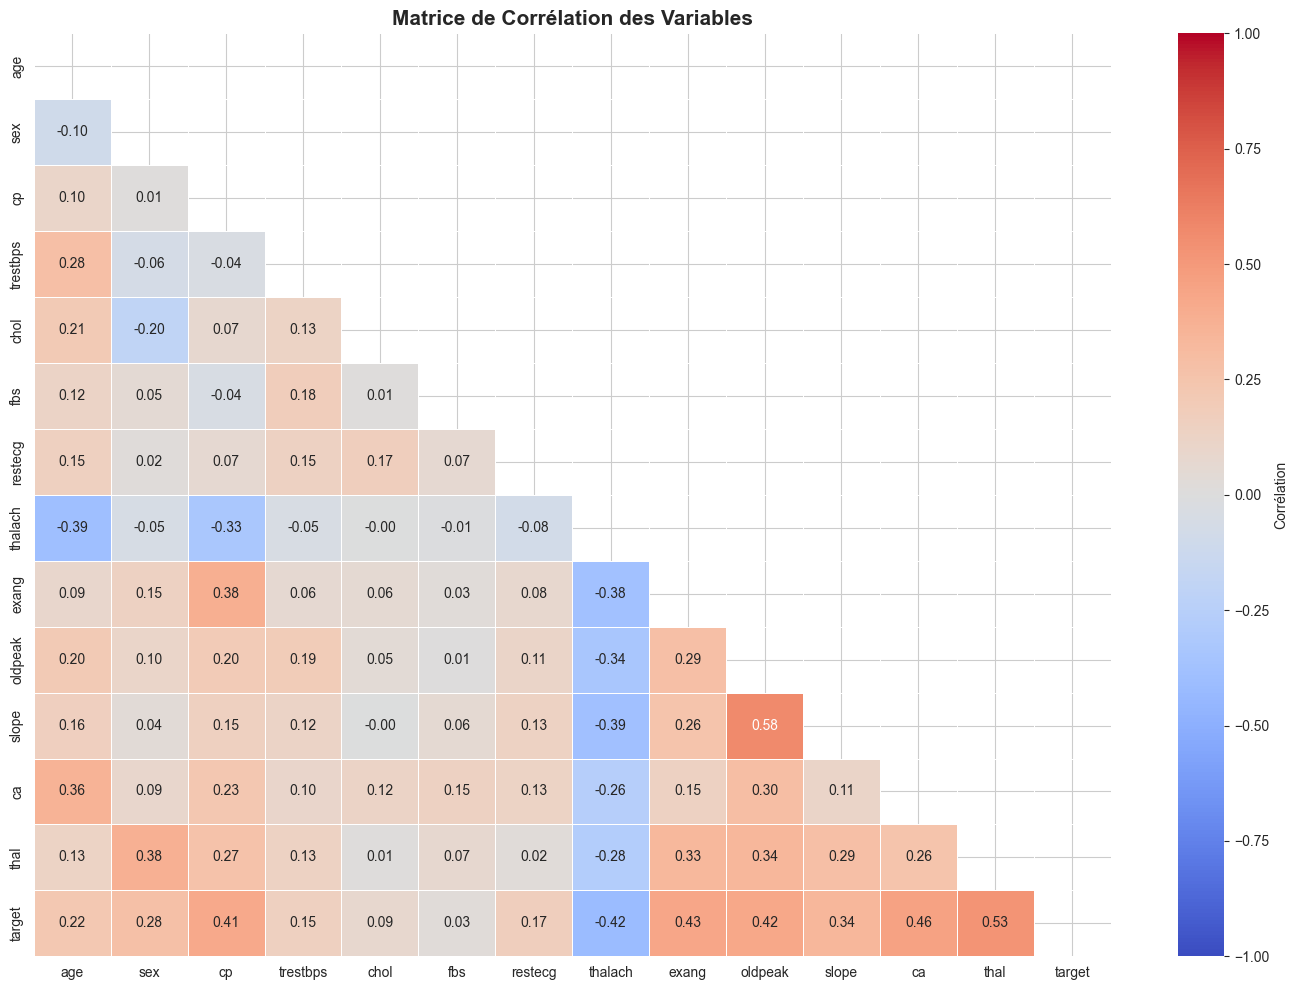

In [15]:
plt.figure(figsize=(14, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={'label': 'Corrélation'})
plt.title('Matrice de Corrélation des Variables', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('matrice_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
# ⚙️ ÉTAPE 4 : Préparation des Données pour le Machine Learning

In [16]:
# ── Séparation features / target ──
X = df.drop('target', axis=1)
y = df['target']

# ── Gestion des valeurs manquantes (si nécessaire) ──
X = X.fillna(X.median())

print(f'Features (X) : {X.shape}')
print(f'Target  (y)  : {y.shape}')
print(f'Colonnes : {list(X.columns)}')

Features (X) : (303, 13)
Target  (y)  : (303,)
Colonnes : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [17]:
# ── Division Train / Test (80% / 20%) ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Taille d\'entraînement : {X_train.shape[0]} exemples')
print(f'Taille de test        : {X_test.shape[0]} exemples')

Taille d'entraînement : 242 exemples
Taille de test        : 61 exemples


In [18]:
# ── Normalisation des données ──
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('✅ Données normalisées avec StandardScaler')

✅ Données normalisées avec StandardScaler


---
# 🤖 ÉTAPE 5 : Entraînement des 6 Algorithmes de Classification

In [19]:
# ── Définition des modèles ──
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'SVM':                 SVC(probability=True, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost':            AdaBoostClassifier(n_estimators=100, random_state=42)
}

print('📋 Modèles à entraîner :')
for name in models:
    print(f'  ✓ {name}')

📋 Modèles à entraîner :
  ✓ Logistic Regression
  ✓ KNN
  ✓ SVM
  ✓ Decision Tree
  ✓ Random Forest
  ✓ AdaBoost


In [20]:
# ── Entraînement et évaluation de tous les modèles ──
results = {}

for name, model in models.items():
    print(f'⏳ Entraînement de {name}...')
    
    # Entraînement
    model.fit(X_train_scaled, y_train)
    
    # Prédictions
    y_pred      = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calcul des métriques
    results[name] = {
        'Accuracy'  : accuracy_score(y_test, y_pred),
        'Précision' : precision_score(y_test, y_pred),
        'Rappel'    : recall_score(y_test, y_pred),
        'F1-Score'  : f1_score(y_test, y_pred),
        'AUC-ROC'   : roc_auc_score(y_test, y_pred_proba)
    }
    print(f'  ✅ {name} → Accuracy: {results[name]["Accuracy"]:.3f}')

print('\n🎉 Tous les modèles sont entraînés !')

⏳ Entraînement de Logistic Regression...
  ✅ Logistic Regression → Accuracy: 0.869
⏳ Entraînement de KNN...
  ✅ KNN → Accuracy: 0.885
⏳ Entraînement de SVM...
  ✅ SVM → Accuracy: 0.852
⏳ Entraînement de Decision Tree...
  ✅ Decision Tree → Accuracy: 0.721
⏳ Entraînement de Random Forest...
  ✅ Random Forest → Accuracy: 0.885
⏳ Entraînement de AdaBoost...
  ✅ AdaBoost → Accuracy: 0.902

🎉 Tous les modèles sont entraînés !


---
# 📊 ÉTAPE 6 : Comparaison des Résultats

In [21]:
# ── Tableau comparatif des métriques ──
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('F1-Score', ascending=False)
results_df_pct = (results_df * 100).round(2)

print('='*70)
print('📊 TABLEAU COMPARATIF DES ALGORITHMES (en %)')
print('='*70)
print(results_df_pct.to_string())
print('\n🏆 Meilleur modèle (F1-Score) :', results_df['F1-Score'].idxmax())

📊 TABLEAU COMPARATIF DES ALGORITHMES (en %)
                     Accuracy  Précision  Rappel  F1-Score  AUC-ROC
AdaBoost                90.16      84.38   96.43     90.00    97.40
KNN                     88.52      80.00  100.00     88.89    92.32
Random Forest           88.52      81.82   96.43     88.52    95.13
Logistic Regression     86.89      81.25   92.86     86.67    95.13
SVM                     85.25      80.65   89.29     84.75    94.37
Decision Tree           72.13      65.71   82.14     73.02    72.89

🏆 Meilleur modèle (F1-Score) : AdaBoost


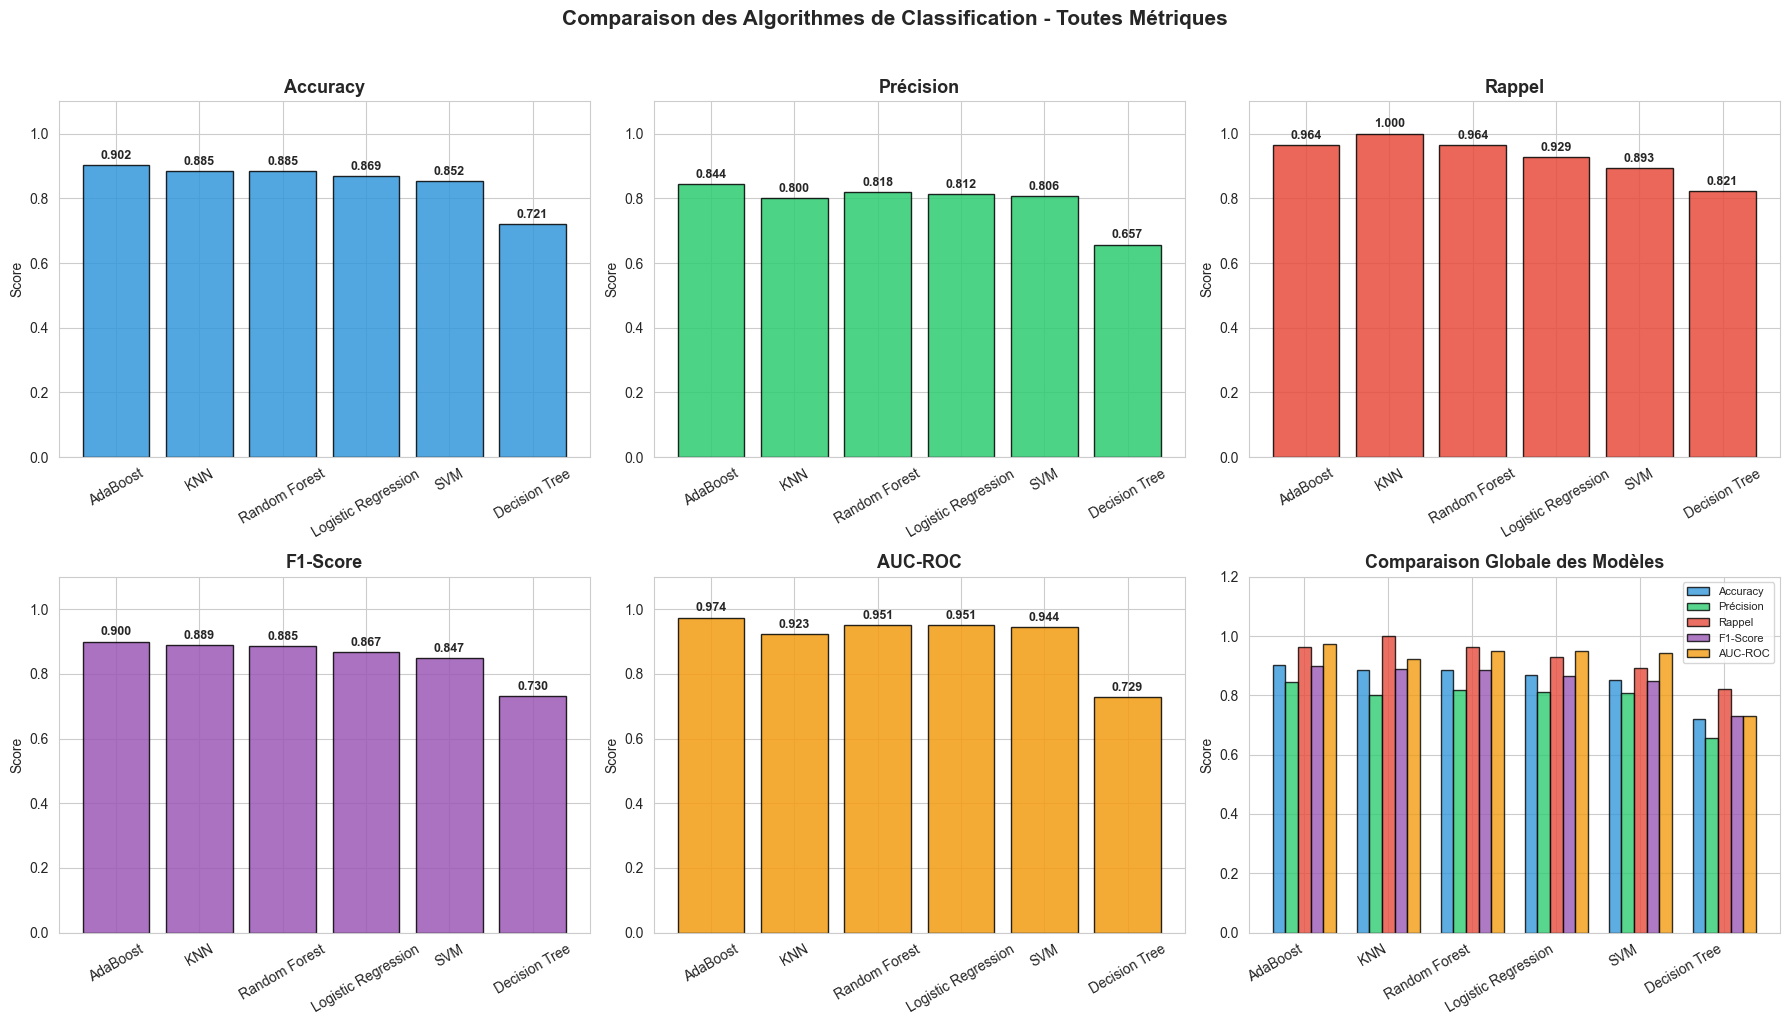

In [22]:
# ── Visualisation des métriques ──
metrics = ['Accuracy', 'Précision', 'Rappel', 'F1-Score', 'AUC-ROC']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    values = results_df[metric]
    bars = axes[i].bar(values.index, values.values, color=colors[i],
                        edgecolor='black', alpha=0.85)
    axes[i].set_title(f'{metric}', fontsize=13, fontweight='bold')
    axes[i].set_ylim(0, 1.1)
    axes[i].set_ylabel('Score')
    axes[i].tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, values.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Graphique de synthèse
x = np.arange(len(results_df.index))
width = 0.15
for j, (metric, color) in enumerate(zip(metrics, colors)):
    axes[5].bar(x + j*width, results_df[metric].values, width,
                label=metric, color=color, edgecolor='black', alpha=0.8)
axes[5].set_title('Comparaison Globale des Modèles', fontsize=13, fontweight='bold')
axes[5].set_xticks(x + width * 2)
axes[5].set_xticklabels(results_df.index, rotation=30, ha='right')
axes[5].set_ylim(0, 1.2)
axes[5].set_ylabel('Score')
axes[5].legend(loc='upper right', fontsize=8)

plt.suptitle('Comparaison des Algorithmes de Classification - Toutes Métriques',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()

## 📈 Courbes ROC de tous les modèles

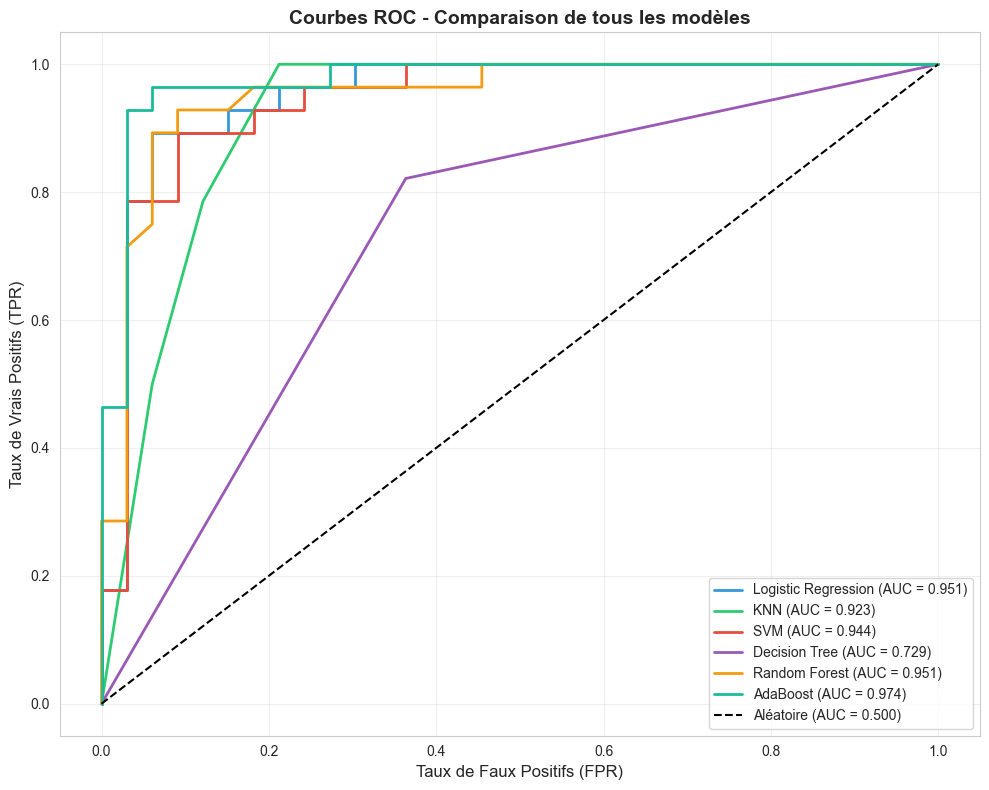

In [23]:
plt.figure(figsize=(10, 8))
colors_roc = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c']

for (name, model), color in zip(models.items(), colors_roc):
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Aléatoire (AUC = 0.500)')
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbes ROC - Comparaison de tous les modèles', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('courbes_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔥 Matrices de Confusion

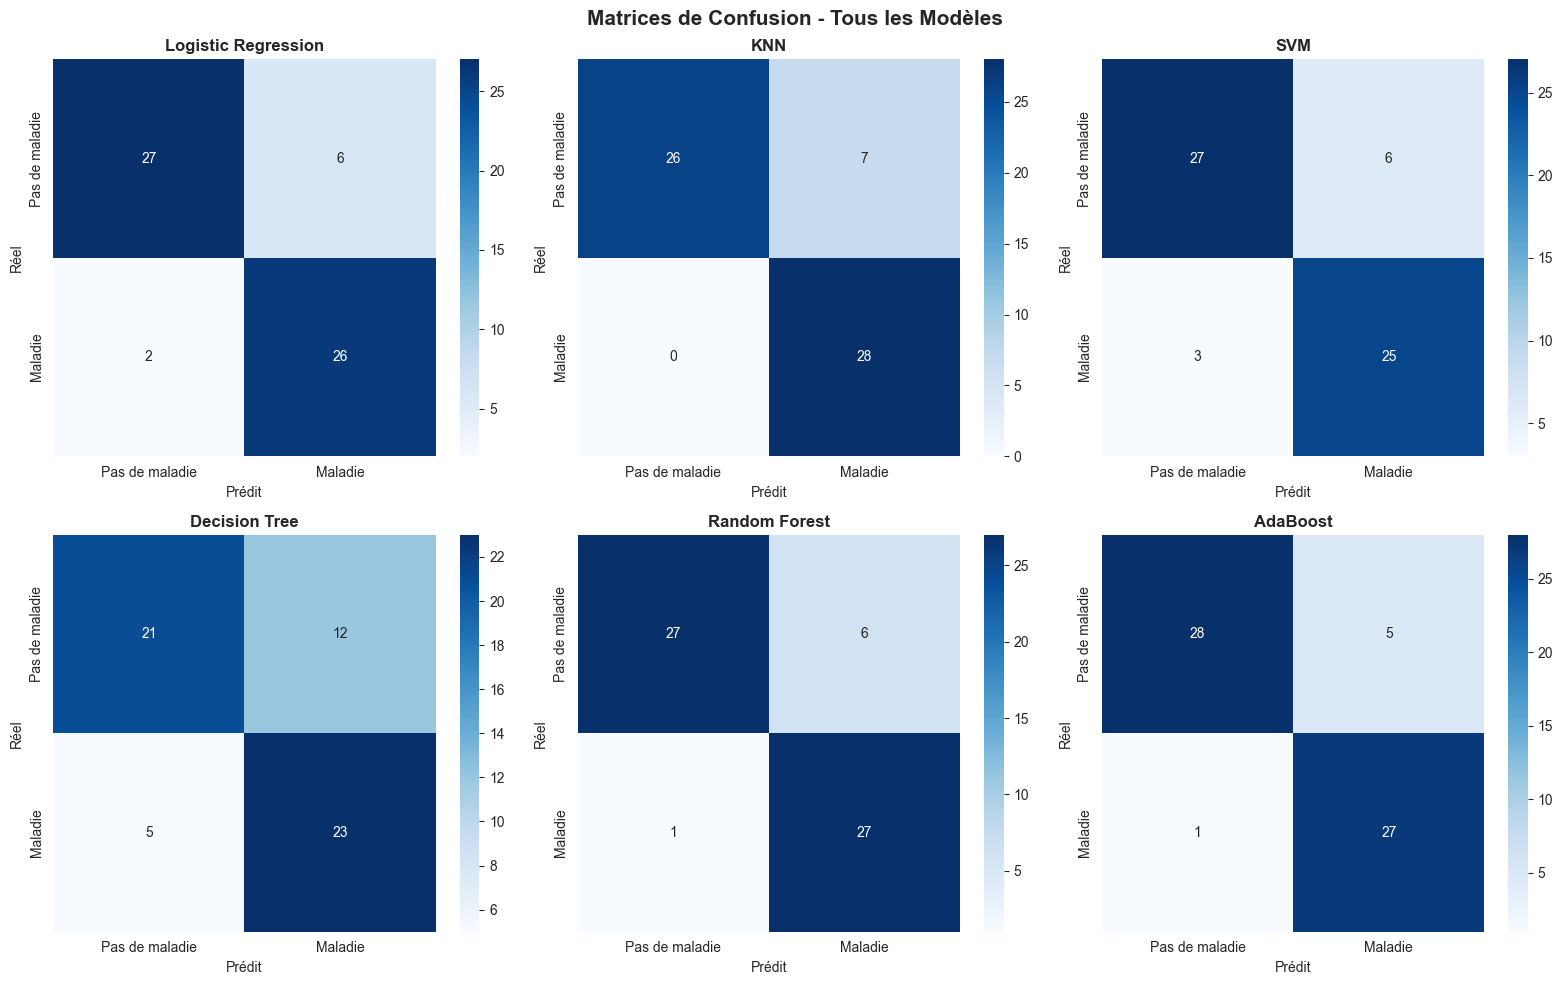

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Pas de maladie', 'Maladie'],
                yticklabels=['Pas de maladie', 'Maladie'])
    axes[i].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Prédit')
    axes[i].set_ylabel('Réel')

plt.suptitle('Matrices de Confusion - Tous les Modèles', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 🌳 Importance des Features (Random Forest)

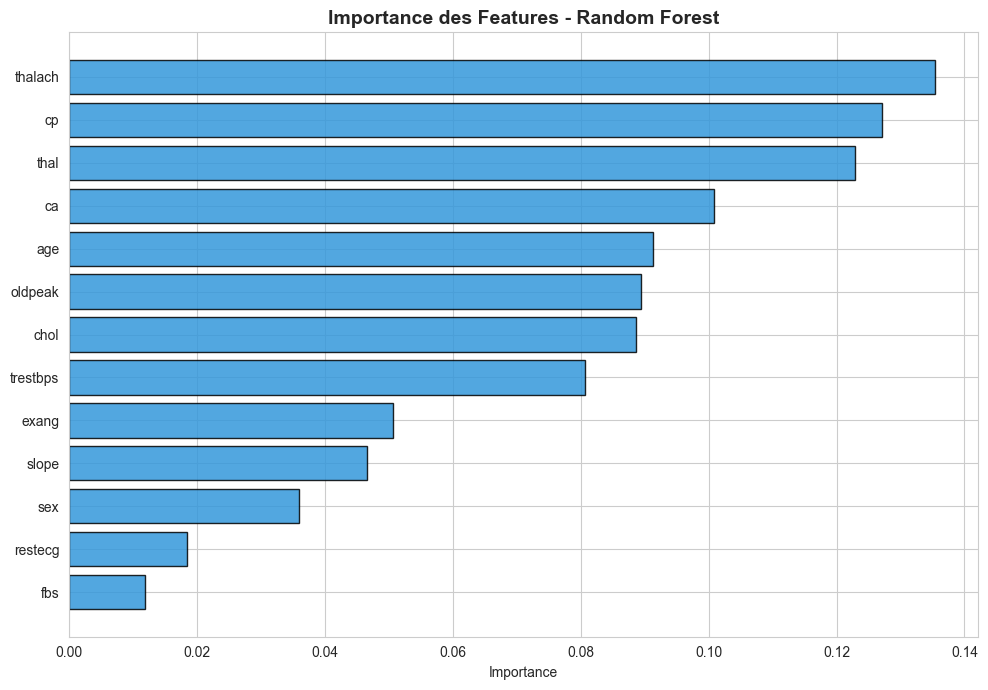


🔑 Top 5 features les plus importantes :
Feature  Importance
thalach    0.135404
     cp    0.127163
   thal    0.122940
     ca    0.100811
    age    0.091327


In [25]:
rf_model = models['Random Forest']
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 7))
bars = plt.barh(feature_importance['Feature'], feature_importance['Importance'],
                color='#3498db', edgecolor='black', alpha=0.85)
plt.title('Importance des Features - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('importance_features.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n🔑 Top 5 features les plus importantes :')
print(feature_importance.sort_values('Importance', ascending=False).head(5).to_string(index=False))

---
# 🏆 ÉTAPE 7 : Conclusion et Recommandations

In [26]:
print('='*70)
print('🏆 RÉSUMÉ FINAL - COMPARAISON DES MODÈLES')
print('='*70)
print(results_df_pct.to_string())

best_model_f1  = results_df['F1-Score'].idxmax()
best_model_acc = results_df['Accuracy'].idxmax()
best_model_auc = results_df['AUC-ROC'].idxmax()

print(f'\n🥇 Meilleur modèle par F1-Score  : {best_model_f1} ({results_df.loc[best_model_f1, "F1-Score"]*100:.2f}%)')
print(f'🥇 Meilleur modèle par Accuracy  : {best_model_acc} ({results_df.loc[best_model_acc, "Accuracy"]*100:.2f}%)')
print(f'🥇 Meilleur modèle par AUC-ROC   : {best_model_auc} ({results_df.loc[best_model_auc, "AUC-ROC"]*100:.2f}%)')

print('\n📝 RECOMMANDATION :')
print(f"   Le modèle '{best_model_f1}' est recommandé pour ce problème médical")
print('   car il offre le meilleur équilibre entre précision et rappel (F1-Score).')
print('   Dans un contexte médical, le rappel est crucial pour ne pas manquer')
print('   de cas de maladies cardiaques réels.')

🏆 RÉSUMÉ FINAL - COMPARAISON DES MODÈLES
                     Accuracy  Précision  Rappel  F1-Score  AUC-ROC
AdaBoost                90.16      84.38   96.43     90.00    97.40
KNN                     88.52      80.00  100.00     88.89    92.32
Random Forest           88.52      81.82   96.43     88.52    95.13
Logistic Regression     86.89      81.25   92.86     86.67    95.13
SVM                     85.25      80.65   89.29     84.75    94.37
Decision Tree           72.13      65.71   82.14     73.02    72.89

🥇 Meilleur modèle par F1-Score  : AdaBoost (90.00%)
🥇 Meilleur modèle par Accuracy  : AdaBoost (90.16%)
🥇 Meilleur modèle par AUC-ROC   : AdaBoost (97.40%)

📝 RECOMMANDATION :
   Le modèle 'AdaBoost' est recommandé pour ce problème médical
   car il offre le meilleur équilibre entre précision et rappel (F1-Score).
   Dans un contexte médical, le rappel est crucial pour ne pas manquer
   de cas de maladies cardiaques réels.


---
# 💾 ÉTAPE 8 : Sauvegarde du Meilleur Modèle

In [27]:
import pickle

# Sauvegarder le meilleur modèle
best_model = models[best_model_f1]

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f'✅ Modèle "{best_model_f1}" sauvegardé dans best_model.pkl')
print('✅ Scaler sauvegardé dans scaler.pkl')
print('\n➡️  Ces fichiers seront utilisés dans l\'application Streamlit')

✅ Modèle "AdaBoost" sauvegardé dans best_model.pkl
✅ Scaler sauvegardé dans scaler.pkl

➡️  Ces fichiers seront utilisés dans l'application Streamlit
